In [ ]:
import subprocess, sys
def run(cmd):
    print(f">> {cmd}")
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    if result.stdout: print(result.stdout[-3000:])
    if result.stderr: print(result.stderr[-1000:])
    return result.returncode

# Install PyTorch with CUDA 12.8 (Blackwell support)
rc = run(f"{sys.executable} -m pip install torch==2.9.1 torchvision==0.24.1 torchaudio==2.9.1 "
         "--index-url https://download.pytorch.org/whl/cu128 --quiet")
if rc != 0:
    print("\n⚠ cu128 install failed — trying cu129 fallback...")
    run(f"{sys.executable} -m pip install torch==2.9.1 torchvision==0.24.1 torchaudio==2.9.1 "
        "--index-url https://download.pytorch.org/whl/cu129 --quiet")

# Other dependencies
run(f"{sys.executable} -m pip install wfdb scipy scikit-learn matplotlib numpy onnx onnxscript --quiet")
run("apt-get update")
run("apt-get install -y build-essential")
print("\n✓ Installation complete — restart kernel now.")

>> /usr/bin/python3 -m pip install torch==2.9.1 torchvision==0.24.1 torchaudio==2.9.1 --index-url https://download.pytorch.org/whl/cu128 --quiet
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 96.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 110.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 139.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 29.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 50.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 54.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 10.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 MB 62.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.2/288.2 MB 90.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.2/287.2 MB 94.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3

In [ ]:
import os, math, time, copy, gc, warnings
from pathlib import Path
import numpy as np
import wfdb
from scipy import signal as scipy_signal
from scipy.sparse.linalg import svds
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch.cuda.amp import GradScaler, autocast
warnings.filterwarnings('ignore')

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    device = torch.device('cuda')
    props = torch.cuda.get_device_properties(0)
    print(f"GPU             : {props.name}")
    print(f"Compute Cap.    : sm_{props.major}{props.minor}")
    print(f"VRAM            : {props.total_memory / 1e9:.1f} GB")
    USE_AMP = True
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device('cpu')
    USE_AMP = False
    print("⚠ No CUDA GPU found — running on CPU")
print(f"Device          : {device}")
print(f"Mixed Precision : {USE_AMP}")

PyTorch version : 2.9.1+cu128
CUDA available  : False
⚠ No CUDA GPU found — running on CPU
Device          : cpu
Mixed Precision : False


In [ ]:
class PTBVCGLoader:
    def __init__(self, vcg_lead_indices=[12,13,14]):
        self.vcg_lead_indices = vcg_lead_indices
    def load_vcg_from_record(self, record_path):
        try:
            record = wfdb.rdrecord(record_path)
            if record.p_signal.shape[1] < 15: return None
            vcg = record.p_signal[:, self.vcg_lead_indices]
            if np.isnan(vcg).any() or np.abs(vcg).max() == 0: return None
            return vcg
        except: return None
    def load_all_vcg_from_database(self, data_dir, output_dir, max_records=None):
        Path(output_dir).mkdir(parents=True, exist_ok=True)
        data_path = Path(data_dir)
        patient_dirs = sorted([d for d in data_path.iterdir() if d.is_dir() and d.name.startswith('patient')])
        print(f"Found {len(patient_dirs)} patient directories")
        vcg_files, count = [], 0
        for pdir in patient_dirs:
            for hea in sorted(pdir.glob('*.hea')):
                if max_records and count >= max_records: break
                rec = str(hea).replace('.hea','')
                vcg = self.load_vcg_from_record(rec)
                if vcg is not None:
                    out = f"{output_dir}/vcg_{pdir.name}_{hea.stem}.npy"
                    np.save(out, vcg)
                    vcg_files.append(out)
                    count += 1
                if count % 50 == 0: print(f"  Progress: {count} records")
            if max_records and count >= max_records: break
        print(f"\n✓ Processed {count} records → {output_dir}")
        return vcg_files



In [ ]:
class VCGPreprocessor:
    def __init__(self, cutoff_freq=40, fs=1000, order=4):
        self.mean = self.std = None
        nyq = 0.5 * fs
        self.b, self.a = scipy_signal.butter(order, cutoff_freq/nyq, btype='low')
    def butterworth_filter(self, data):
        out = np.zeros_like(data)
        for i in range(data.shape[1]):
            out[:,i] = scipy_signal.filtfilt(self.b, self.a, data[:,i])
        return out
    def fit_normalisation(self, sample_signals):
        """Fit mean/std on a list of 2D arrays (T,3)"""
        concat = np.concatenate(sample_signals, axis=0)
        self.mean = concat.mean(axis=0, keepdims=True)
        self.std  = concat.std(axis=0, keepdims=True) + 1e-8
    def normalize(self, data):
        return (data - self.mean) / self.std
    def preprocess(self, data, fit=False):
        """Apply filter + normalisation. If fit=True, compute stats from this single record (legacy)."""
        filtered = self.butterworth_filter(data)
        return self.normalize(filtered)



In [ ]:
PATCH_SIZE = 1000
WINDOW_SIZE = 10000
PATCHES_PER_WINDOW = WINDOW_SIZE // PATCH_SIZE

class VCGDataGenerator:
    """
    Generates random 10s windows -> splits into 10 patches of 1s.
    Each call to `train_generator` yields (patches, patches) of shape
    (batch_size * 10, 1000, 3).
    """
    def __init__(self, batch_size=128, test_records=5):
        self.batch_size = batch_size
        self.test_records = test_records

    def prepare_dataset(self, vcg_files, preprocessor):
        """Load all records, preprocess, keep test records aside."""
        print("\nLoading and preprocessing records...")
        all_records = []
        for i, f in enumerate(vcg_files):
            if i % 50 == 0: print(f"{i+1}/{len(vcg_files)}")
            signal = np.load(f).astype(np.float32)
            signal = preprocessor.preprocess(signal)
            if signal.shape[0] >= WINDOW_SIZE:
                all_records.append(signal)
        # Shuffle and split
        rng = np.random.default_rng(42)
        rng.shuffle(all_records)
        train_records = all_records[:-self.test_records]
        test_records  = all_records[-self.test_records:]
        print(f"\nTraining records : {len(train_records)}")
        print(f"Testing records  : {len(test_records)}")
        return train_records, test_records

    def random_batch(self, records):
        """Return a batch of full 10s windows: (batch_size, 10000, 3)"""
        batch = np.empty((self.batch_size, WINDOW_SIZE, 3), dtype=np.float32)
        for i in range(self.batch_size):
            rec = records[np.random.randint(len(records))]
            start = np.random.randint(0, rec.shape[0] - WINDOW_SIZE + 1)
            batch[i] = rec[start:start+WINDOW_SIZE]
        return batch

    def train_generator(self, records):
        """Yields (patches, patches) as numpy arrays."""
        while True:
            windows = self.random_batch(records)                     # (B, 10000, 3)
            # Reshape to (B*10, 1000, 3)
            patches = windows.reshape(-1, PATCH_SIZE, 3)
            yield patches, patches

    def validation_generator(self, records):
        """Same as train_generator (no ground truth leak)."""
        return self.train_generator(records)



In [ ]:
# ==============================================================================
# CELL 5 — Positional Encoding (Vaswani et al.)
# ==============================================================================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len, dtype=torch.float).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0)/d_model))
        pe[:,0::2] = torch.sin(pos * div)
        pe[:,1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))   # (1, max_len, d_model)
    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])



In [ ]:
# ==============================================================================
# CELL 6 — TCN Residual Block
# ==============================================================================
class TCNResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation, dropout=0.1):
        super().__init__()
        padding = (kernel_size - 1) * dilation
        self.net = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size, dilation=dilation, padding=padding),
            nn.GroupNorm(1, out_channels),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Conv1d(out_channels, out_channels, kernel_size, dilation=dilation, padding=padding),
            nn.GroupNorm(1, out_channels),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.chomp = padding
        self.downsample = nn.Conv1d(in_channels, out_channels, 1) if in_channels != out_channels else None
        self.activation = nn.GELU()

    def _chomp(self, x):
        return x[:,:,:-self.chomp].contiguous() if self.chomp > 0 else x

    def forward(self, x):
        out = x
        for layer in self.net:
            out = layer(out)
            if isinstance(layer, nn.Conv1d):
                out = self._chomp(out)
        res = self.downsample(x) if self.downsample else x
        return self.activation(out + res)

In [ ]:
# ==============================================================================
# CELL 7 — TCN Encoder
# ==============================================================================
class TCNEncoder(nn.Module):
    def __init__(self, seq_len=1000, in_ch=3, hidden_ch=64, n_levels=4,
                 kernel_size=3, bottleneck_dim=150, dropout=0.1):
        super().__init__()
        self.seq_len = seq_len
        tcn_blocks = []
        ch_in = in_ch
        for i in range(n_levels):
            tcn_blocks.append(TCNResidualBlock(ch_in, hidden_ch, kernel_size, 2**i, dropout))
            ch_in = hidden_ch
        self.tcn = nn.Sequential(*tcn_blocks)

        # Strided downsampling: /16
        self.down = nn.Sequential(
            nn.Conv1d(hidden_ch, hidden_ch*2, 3, stride=2, padding=1), nn.GELU(),
            nn.Conv1d(hidden_ch*2, hidden_ch*2, 3, stride=2, padding=1), nn.GELU(),
            nn.Conv1d(hidden_ch*2, hidden_ch*2, 3, stride=2, padding=1), nn.GELU(),
            nn.Conv1d(hidden_ch*2, hidden_ch*2, 3, stride=2, padding=1), nn.GELU(),
        )
        self._flat_dim = (hidden_ch*2) * math.ceil(seq_len/16)
        self.bottleneck = nn.Sequential(
            nn.Linear(self._flat_dim, bottleneck_dim),
            nn.ReLU()
        )

    def forward(self, x):
        x = x.permute(0,2,1)   # (B,C,T)
        x = self.tcn(x)
        x = self.down(x)
        x = x.flatten(1)
        return self.bottleneck(x)


In [ ]:
# ==============================================================================
# CELL 8 — Transformer Bottleneck
# ==============================================================================
class TransformerBottleneck(nn.Module):
    def __init__(self, bottleneck_dim, n_patches=10, d_model=64, nhead=4,
                 num_layers=2, dropout=0.1):
        super().__init__()
        assert bottleneck_dim % n_patches == 0
        self.n_patches = n_patches
        self.patch_dim = bottleneck_dim // n_patches
        self.patch_embed = nn.Linear(self.patch_dim, d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len=n_patches+1, dropout=dropout)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model*4,
            dropout=dropout, activation='gelu', batch_first=True, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.proj_out = nn.Linear(d_model * n_patches, bottleneck_dim)

    def forward(self, z):
        B = z.size(0)
        tokens = z.view(B, self.n_patches, self.patch_dim)
        tokens = self.patch_embed(tokens)
        tokens = self.pos_enc(tokens)
        tokens = self.transformer(tokens)
        tokens = tokens.flatten(1)
        return self.proj_out(tokens)




In [ ]:
# ==============================================================================
# CELL 9 — TCN Decoder
# ==============================================================================
class TCNDecoder(nn.Module):
    def __init__(self, seq_len=1000, out_ch=3, hidden_ch=64, n_levels=4,
                 kernel_size=3, bottleneck_dim=150, dropout=0.1):
        super().__init__()
        self.seq_len = seq_len
        self.hidden_ch = hidden_ch
        self.flat_len = math.ceil(seq_len/16)
        self._flat_dim = (hidden_ch*2) * self.flat_len
        self.expand = nn.Sequential(
            nn.Linear(bottleneck_dim, self._flat_dim), nn.ReLU()
        )
        # Upsample ×16
        self.up = nn.Sequential(
            nn.ConvTranspose1d(hidden_ch*2, hidden_ch*2, 4, stride=2, padding=1), nn.GELU(),
            nn.ConvTranspose1d(hidden_ch*2, hidden_ch*2, 4, stride=2, padding=1), nn.GELU(),
            nn.ConvTranspose1d(hidden_ch*2, hidden_ch, 4, stride=2, padding=1), nn.GELU(),
            nn.ConvTranspose1d(hidden_ch, hidden_ch, 4, stride=2, padding=1), nn.GELU(),
        )
        tcn_blocks = []
        for i in range(n_levels):
            tcn_blocks.append(TCNResidualBlock(hidden_ch, hidden_ch, kernel_size, 2**i, dropout))
        self.tcn = nn.Sequential(*tcn_blocks)
        self.out_conv = nn.Conv1d(hidden_ch, out_ch, 1)

    def forward(self, z):
        x = self.expand(z)
        x = x.view(x.size(0), self.hidden_ch*2, self.flat_len)
        x = self.up(x)
        if x.size(2) > self.seq_len:
            x = x[:,:,:self.seq_len]
        elif x.size(2) < self.seq_len:
            x = F.pad(x, (0, self.seq_len - x.size(2)))
        x = self.tcn(x)
        x = self.out_conv(x)
        return x.permute(0,2,1)

In [ ]:
# ==============================================================================
# CELL 10 — Full Autoencoder
# ==============================================================================
class VCGCompressionModel(nn.Module):
    def __init__(self, seq_len=1000, in_channels=3, hidden_ch=64, n_tcn_levels=4,
                 kernel_size=3, bottleneck_dim=150, transformer_patches=10,
                 d_model=64, nhead=4, num_layers=2, dropout=0.1, compression_ratio=20):
        super().__init__()
        self.encoder = TCNEncoder(seq_len, in_channels, hidden_ch, n_tcn_levels,
                                  kernel_size, bottleneck_dim, dropout)
        self.bottleneck = TransformerBottleneck(bottleneck_dim, transformer_patches,
                                                d_model, nhead, num_layers, dropout)
        self.decoder = TCNDecoder(seq_len, in_channels, hidden_ch, n_tcn_levels,
                                  kernel_size, bottleneck_dim, dropout)

    def encode(self, x):
        z = self.encoder(x)
        return self.bottleneck(z)

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        return self.decode(self.encode(x))

    def count_params(self):
        return sum(p.numel() for p in self.parameters())

In [ ]:
# ==============================================================================
# CELL 11 — Direct PRD Loss (optimizes exactly what we measure)
# ==============================================================================
def vcg_loss(pred, target, freq_weight=0.1):
    """
    Direct PRD loss: minimizes sqrt(sum((x-xhat)^2)/sum(x^2))
    This is exactly the PRD formula, so training directly minimizes what we measure.
    """
    # Primary: Direct PRD proxy (per-sample, then averaged)
    num = torch.sum((pred - target) ** 2, dim=[1, 2])          # (B,)
    den = torch.sum(target ** 2, dim=[1, 2]) + 1e-8            # (B,)
    prd_loss = torch.mean(torch.sqrt(num / den))               # scalar PRD in [0,1]

    # Secondary: Frequency regularizer to preserve QRS/T morphology
    pred_fft   = torch.fft.rfft(pred.float(),   dim=1)
    target_fft = torch.fft.rfft(target.float(), dim=1)
    n_freqs = pred_fft.size(1)
    freq_loss = F.mse_loss(pred_fft.abs() / n_freqs**0.5,
                           target_fft.abs() / n_freqs**0.5)

    return prd_loss + freq_weight * freq_loss


In [ ]:
# ==============================================================================
# CELL 12 — VCGTrainer (with OneCycleLR scheduler)
# ==============================================================================
class VCGTrainer:
    def __init__(self, model, device, use_amp=True, use_compile=False):
        self.device = device
        self.use_amp = use_amp and device.type == 'cuda'
        self.model = model.to(device)
        if use_compile and device.type == 'cuda':
            try:
                self.model = torch.compile(self.model)
                print('torch.compile() enabled')
            except Exception as e:
                print(f'  torch.compile() skipped: {e}')
        self.scaler = GradScaler(enabled=self.use_amp)
        self.history = {'train_loss':[], 'val_loss':[], 'train_prd':[], 'val_prd':[]}
        self._best_state = None
        self._best_val = float('inf')

    def train(self, train_gen, val_gen, steps_per_epoch=200, validation_steps=20,
              epochs=100, lr=3e-4, patience=30, weight_decay=1e-4,
              grad_accum_steps=2, freq_weight=0.1):
        optimizer = torch.optim.AdamW(self.model.parameters(), lr=lr, weight_decay=weight_decay)
        # OneCycleLR: ramps up for 30% of training then anneals — best for fixed-epoch training
        scheduler = torch.optim.lr_scheduler.OneCycleLR(
            optimizer, max_lr=lr,
            steps_per_epoch=steps_per_epoch, epochs=epochs,
            pct_start=0.3, div_factor=10, final_div_factor=1000
        )
        no_improve = 0
        print(f'\nTraining: {epochs} epochs | {steps_per_epoch} steps/epoch | lr {lr} | AMP {self.use_amp}')
        print(f'Gradient accumulation: {grad_accum_steps} | freq_loss weight: {freq_weight}')
        print('-'*70)

        for epoch in range(1, epochs+1):
            t0 = time.time()
            self.model.train()
            train_loss = 0.0
            for step in range(steps_per_epoch):
                xb, yb = next(train_gen)
                if step % 50 == 0:
                    print(f'  [Epoch {epoch}] Step {step}/{steps_per_epoch}...', end='\r')
                xb = torch.from_numpy(xb).float().to(self.device, non_blocking=True)
                yb = torch.from_numpy(yb).float().to(self.device, non_blocking=True)

                micro_batch_size = max(1, xb.size(0) // grad_accum_steps)
                optimizer.zero_grad(set_to_none=True)
                micro_loss_sum = 0.0
                for i in range(grad_accum_steps):
                    start = i * micro_batch_size
                    end   = min(start + micro_batch_size, xb.size(0))
                    xb_micro = xb[start:end]
                    yb_micro = yb[start:end]
                    with autocast(enabled=self.use_amp):
                        pred = self.model(xb_micro)
                        loss = vcg_loss(pred, yb_micro, freq_weight=freq_weight) / grad_accum_steps
                    self.scaler.scale(loss).backward()
                    micro_loss_sum += loss.item() * grad_accum_steps

                self.scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                self.scaler.step(optimizer)
                self.scaler.update()
                scheduler.step()

                train_loss += micro_loss_sum / grad_accum_steps

            train_loss /= steps_per_epoch

            # Validation
            self.model.eval()
            val_loss = 0.0
            with torch.no_grad(), autocast(enabled=self.use_amp):
                for _ in range(validation_steps):
                    xb, yb = next(val_gen)
                    xb = torch.from_numpy(xb).float().to(self.device, non_blocking=True)
                    yb = torch.from_numpy(yb).float().to(self.device, non_blocking=True)
                    pred = self.model(xb)
                    val_loss += vcg_loss(pred, yb, freq_weight=freq_weight).item()
            val_loss /= validation_steps

            # Estimate PRD from validation loss (prd_loss is the dominant term)
            est_prd = val_loss * 100  # rough PRD % estimate

            improved = val_loss < self._best_val
            if improved:
                self._best_val = val_loss
                self._best_state = copy.deepcopy(self.model.state_dict())
                no_improve = 0
                tag = ' * best'
            else:
                no_improve += 1
                tag = ''

            dt = time.time() - t0
            current_lr = scheduler.get_last_lr()[0]
            print(f'Epoch {epoch:3d}/{epochs} | loss {train_loss:.4f} | val {val_loss:.4f} '
                  f'| est PRD ~{est_prd:.1f}% | lr {current_lr:.2e} | {dt:.1f}s{tag}')

            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)

            # Early stopping only after 50 epochs minimum
            if epoch >= 50 and no_improve >= patience:
                print(f'\nEarly stopping at epoch {epoch} (patience={patience})')
                break

        if self._best_state:
            self.model.load_state_dict(self._best_state)
        print(f'\nBest val loss: {self._best_val:.5f} | est PRD ~{self._best_val*100:.1f}%')
        return self.history

    def predict(self, X, batch_size=128):
        self.model.eval()
        loader = DataLoader(TensorDataset(torch.FloatTensor(X)), batch_size=batch_size,
                           shuffle=False, num_workers=0, pin_memory=True)
        out = []
        with torch.no_grad(), autocast(enabled=self.use_amp):
            for (xb,) in loader:
                xb = xb.to(self.device, non_blocking=True)
                out.append(self.model(xb).cpu().float().numpy())
        return np.concatenate(out, axis=0)

    def encode(self, X, batch_size=128):
        self.model.eval()
        loader = DataLoader(TensorDataset(torch.FloatTensor(X)), batch_size=batch_size,
                           shuffle=False, num_workers=0, pin_memory=True)
        out = []
        with torch.no_grad(), autocast(enabled=self.use_amp):
            for (xb,) in loader:
                xb = xb.to(self.device, non_blocking=True)
                out.append(self.model.encode(xb).cpu().float().numpy())
        return np.concatenate(out, axis=0)



In [ ]:
# ==============================================================================
# CELL 13 — Matrix Completion (SVD‑based denoising)
# ==============================================================================
class MatrixCompletion:
    def __init__(self, rank=15, iterations=10):
        self.rank = rank
        self.iterations = iterations

    def _complete_single(self, sig):
        X = sig.copy()
        for i in range(self.iterations):
            try:
                if X.shape[0] > self.rank and X.shape[1] > self.rank:
                    U, s, Vt = svds(X, k=min(self.rank, min(X.shape)-1))
                    idx = np.argsort(s)[::-1]
                    U, s, Vt = U[:,idx], s[idx], Vt[idx,:]
                else:
                    U, s, Vt = np.linalg.svd(X, full_matrices=False)
                    U, s, Vt = U[:,:self.rank], s[:self.rank], Vt[:self.rank,:]
                Xc = U @ np.diag(s) @ Vt
                X = Xc   # no reference mixing
            except Exception as e:
                print(f"  MC warning iter {i}: {e}")
                return sig
        return X

    def complete_matrix(self, incomplete):
        if incomplete.ndim == 3:
            return np.array([self._complete_single(incomplete[i]) for i in range(incomplete.shape[0])])
        return self._complete_single(incomplete)



In [ ]:
# ==============================================================================
# CELL 14 — Performance Evaluator
# ==============================================================================
class PerformanceEvaluator:
    @staticmethod
    def mse(orig, recon): return np.mean((orig-recon)**2)
    @staticmethod
    def rmse(orig, recon): return np.sqrt(PerformanceEvaluator.mse(orig, recon))
    @staticmethod
    def prd(orig, recon):
        num = np.sum((orig-recon)**2)
        den = np.sum(orig**2) + 1e-10
        return np.sqrt(num/den)*100
    @staticmethod
    def snr(orig, recon):
        sp = np.sum(orig**2)
        np_ = np.sum((orig-recon)**2)
        return 10*np.log10(sp/(np_+1e-10))
    @staticmethod
    def psnr(orig, recon):
        mv = np.max(np.abs(orig))
        m = PerformanceEvaluator.mse(orig, recon)
        return 10*np.log10((mv**2)/(m+1e-10))
    @staticmethod
    def fidelity(orig, recon):
        dot = np.sum(orig*recon, axis=-1)
        n1 = np.linalg.norm(orig, axis=-1) + 1e-10
        n2 = np.linalg.norm(recon, axis=-1) + 1e-10
        return np.mean(dot/(n1*n2))*100

def evaluate_full(orig, recon, bottleneck_dim, window_size=1000, n_ch=3):
    cr = (window_size*n_ch) / bottleneck_dim
    fid = PerformanceEvaluator.fidelity(orig, recon)
    prd = PerformanceEvaluator.prd(orig, recon)
    psnr = PerformanceEvaluator.psnr(orig, recon)
    qs = cr / (prd+1e-10)
    mse = PerformanceEvaluator.mse(orig, recon)
    rmse = PerformanceEvaluator.rmse(orig, recon)
    snr = PerformanceEvaluator.snr(orig, recon)
    return dict(CR=cr, FID=fid, PRD=prd, PSNR=psnr, QS=qs, MSE=mse, RMSE=rmse, SNR=snr)



In [ ]:
# ==============================================================================
# CELL 15 — Paths, Hyperparams, Normalisation (Auto-Detecting Drive)
# ==============================================================================
import os, sys

# ── Auto-mount Drive & Auto-detect project folder ──────────────────────────────
IN_COLAB = os.path.exists('/content')
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)

    mydrive = '/content/drive/MyDrive'
    # Find any folder in MyDrive containing 'VCG' or 'vcg'
    folders = [f for f in os.listdir(mydrive) if 'vcg' in f.lower()] if os.path.exists(mydrive) else []

    if 'VCG-Signal-Compression-main' in os.listdir(mydrive):
        DRIVE_ROOT = os.path.join(mydrive, 'VCG-Signal-Compression-main')
    elif folders:
        DRIVE_ROOT = os.path.join(mydrive, folders[0])
        print(f"✓ Auto-detected project folder: {folders[0]}")
    else:
        DRIVE_ROOT = mydrive
        print("⚠ Project folder not found, using MyDrive root")

    os.chdir(DRIVE_ROOT)
    print(f'Working directory: {os.getcwd()}')
    MODEL_DIR = '/content/drive/MyDrive/VCG_Models'
else:
    MODEL_DIR = 'models'

DATA_DIR   = 'ptb-diagnostic-ecg-database-1.0.0'
OUTPUT_DIR = 'vcg_data'
RESULT_DIR = 'results'

from pathlib import Path
Path(MODEL_DIR).mkdir(parents=True, exist_ok=True)
Path(RESULT_DIR).mkdir(exist_ok=True)

MAX_RECORDS    = 500
BATCH_SIZE     = 16           # Batch size 16 for GPU memory safety
TEST_RECORDS   = 5
TRAIN_STEPS    = 200
VAL_STEPS      = 30
GRAD_ACCUM     = 4            # Gradient accum 4

CR_LIST = [30]

# Model hyperparams — UPGRADED
HIDDEN_CH           = 128
N_TCN_LEVELS        = 6
KERNEL_SIZE         = 7
TRANSFORMER_PATCHES = 10
D_MODEL             = 128
NHEAD               = 4
NUM_LAYERS          = 4
DROPOUT             = 0.05
FREQ_WEIGHT         = 0.1

EPOCHS   = 100
LR       = 3e-4
PATIENCE = 30

def cr_to_bottleneck(cr, seq_len=1000, n_ch=3, patches=10):
    raw = (seq_len*n_ch)/cr
    bd = max(10, round(raw/patches)*patches)
    actual_cr = (seq_len*n_ch)/bd
    return bd, actual_cr

# ── Load data ────────────────────────────────────────────────────────────────
print('[DATA] Loading VCG files...')
loader = PTBVCGLoader()
vcg_data_path = Path(OUTPUT_DIR)
npy_files = list(vcg_data_path.glob('*.npy')) if vcg_data_path.exists() else []
print(f'  vcg_data path : {vcg_data_path.resolve()}')
print(f'  .npy files    : {len(npy_files)}')

if vcg_data_path.exists() and len(npy_files) >= MAX_RECORDS:
    vcg_files = sorted(str(f) for f in npy_files)
    print(f'Found {len(vcg_files)} cached files')
else:
    vcg_files = loader.load_all_vcg_from_database(DATA_DIR, OUTPUT_DIR, max_records=MAX_RECORDS)

rng = np.random.default_rng(42)
rng.shuffle(vcg_files)

test_files  = vcg_files[-TEST_RECORDS:]
train_files = vcg_files[:-TEST_RECORDS]
print(f'Train files: {len(train_files)}  |  Test files: {len(test_files)}')

preprocessor = VCGPreprocessor(cutoff_freq=40, fs=1000, order=4)
sample_list = []
for f in train_files[:20]:
    d = np.load(f).astype(np.float32)
    sample_list.append(d[::10])
preprocessor.fit_normalisation(sample_list)
del sample_list; gc.collect()
print(f'Normalisation fitted. mean={preprocessor.mean.flatten()[:3]}...')

train_records = []
for f in train_files:
    signal = np.load(f).astype(np.float32)
    signal = preprocessor.preprocess(signal)
    if signal.shape[0] >= WINDOW_SIZE:
        train_records.append(signal)

test_records = []
for f in test_files:
    signal = np.load(f).astype(np.float32)
    signal = preprocessor.preprocess(signal)
    if signal.shape[0] >= WINDOW_SIZE:
        test_records.append(signal)

print(f'Training records : {len(train_records)}')
print(f'Testing records  : {len(test_records)}')

data_gen = VCGDataGenerator(batch_size=BATCH_SIZE, test_records=0)
data_gen.train_records = train_records
data_gen.test_records = test_records


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory: /content/drive/MyDrive/VCG-Signal-Compression-main
[DATA] Loading VCG files...
  vcg_data path : /content/drive/MyDrive/VCG-Signal-Compression-main/vcg_data
  .npy files    : 500
Found 500 cached files
Train files: 495  |  Test files: 5
Normalisation fitted. mean=[ 4.8780719e-05 -4.2112938e-06  4.5564662e-05]...
Training records : 495
Testing records  : 5


In [ ]:
# ==============================================================================
# CELL 16 — Training Loop (CR sweep) — UPGRADED MODEL
# ==============================================================================
mc_refiner = MatrixCompletion(rank=15, iterations=10)
all_rows = []       # per-patient metrics
summary_rows = []   # overall mean per CR

print('='*70)
print('STARTING MULTI-CR SWEEP — Upgraded TCN+Transformer (hidden=128, levels=6)')
print('='*70)

for cr in CR_LIST:
    bottleneck_dim, actual_cr = cr_to_bottleneck(cr)
    print(f"\n{'='*70}")
    print(f"CR = {cr}  |  bottleneck = {bottleneck_dim}  |  actual CR = {actual_cr:.1f}")
    print(f"{'='*70}")

    # Build UPGRADED model
    model = VCGCompressionModel(
        seq_len=PATCH_SIZE, in_channels=3, hidden_ch=HIDDEN_CH,
        n_tcn_levels=N_TCN_LEVELS, kernel_size=KERNEL_SIZE,
        bottleneck_dim=bottleneck_dim, transformer_patches=TRANSFORMER_PATCHES,
        d_model=D_MODEL, nhead=NHEAD, num_layers=NUM_LAYERS,
        dropout=DROPOUT, compression_ratio=cr
    )
    print(f'  Model params: {model.count_params():,}')

    trainer = VCGTrainer(model, device=device, use_amp=USE_AMP, use_compile=False)
    train_gen = data_gen.train_generator(train_records)
    val_gen   = data_gen.validation_generator(test_records)

    # Check if upgraded checkpoint exists
    checkpoint_path = f"{MODEL_DIR}/vcg_model_cr{cr}_v2.pt"  # _v2 = upgraded model
    if os.path.exists(checkpoint_path):
        print(f'Found saved checkpoint at {checkpoint_path}. Skipping training.')
        ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
        model.load_state_dict(ckpt['model_state'])
        history = ckpt.get('history', {'train_loss':[], 'val_loss':[]})
    else:
        # Train with upgraded settings
        t0 = time.time()
        history = trainer.train(
            train_gen, val_gen,
            steps_per_epoch=TRAIN_STEPS,
            validation_steps=VAL_STEPS,
            epochs=EPOCHS,
            lr=LR,
            patience=PATIENCE,
            grad_accum_steps=GRAD_ACCUM,
            freq_weight=FREQ_WEIGHT
        )
        train_time = time.time() - t0
        print(f'Training time: {train_time/60:.1f} min')

        # Save checkpoint immediately after training
        ckpt = {'cr':cr, 'bottleneck_dim':bottleneck_dim, 'actual_cr':actual_cr,
                'model_state':model.state_dict(), 'history':history,
                'hyperparams': {'hidden_ch': HIDDEN_CH, 'n_tcn_levels': N_TCN_LEVELS,
                                'kernel_size': KERNEL_SIZE, 'd_model': D_MODEL,
                                'num_layers': NUM_LAYERS}}
        torch.save(ckpt, checkpoint_path)
        print(f'  Checkpoint saved to {checkpoint_path}')

    # Per-patient evaluation
    NUM_WINDOWS_PER_PATIENT = 100
    rng_eval = np.random.default_rng(42)
    patient_metrics = []

    # Use last patient's patches for reconstruction plot
    last_patches = None

    for p_idx, rec in enumerate(test_records):
        patches = []
        for _ in range(NUM_WINDOWS_PER_PATIENT):
            start = rng_eval.integers(0, rec.shape[0] - PATCH_SIZE + 1)
            patches.append(rec[start:start+PATCH_SIZE])
        patches = np.stack(patches, axis=0)
        if last_patches is None:
            last_patches = patches

        ae_out = trainer.predict(patches)
        mc_out = mc_refiner.complete_matrix(ae_out)

        avg = {k:0.0 for k in ['FID','PRD','PSNR','QS','MSE','RMSE','SNR']}
        for i in range(NUM_WINDOWS_PER_PATIENT):
            m = evaluate_full(patches[i], mc_out[i], bottleneck_dim, PATCH_SIZE, 3)
            for k in avg: avg[k] += m[k]
        for k in avg: avg[k] /= NUM_WINDOWS_PER_PATIENT
        avg['patient'] = p_idx+1
        avg['cr_target'] = cr
        avg['bottleneck_dim'] = bottleneck_dim
        patient_metrics.append(avg)
        print(f"  Patient {p_idx+1}: PRD={avg['PRD']:.2f}%  PSNR={avg['PSNR']:.2f}dB")

    # Mean across patients
    overall = {k: np.mean([p[k] for p in patient_metrics]) for k in ['FID','PRD','PSNR','QS','MSE','RMSE','SNR']}
    overall['patient'] = 'Mean'
    overall['cr_target'] = cr
    overall['bottleneck_dim'] = bottleneck_dim
    patient_metrics.append(overall)
    all_rows.extend(patient_metrics)
    summary_rows.append({**{k:overall[k] for k in ['FID','PRD','PSNR','QS','MSE','RMSE','SNR']},
                         'cr_target':cr, 'bottleneck_dim':bottleneck_dim})

    print(f"\n  CR={cr} OVERALL (AE+MC, {len(test_records)} patients):")
    print(f"    FID  : {overall['FID']:.2f}%")
    print(f"    PRD  : {overall['PRD']:.2f}%")
    print(f"    PSNR : {overall['PSNR']:.2f} dB")
    print(f"    QS   : {overall['QS']:.2f} %-1")
    print(f"    SNR  : {overall['SNR']:.2f} dB")
    print(f"    MSE  : {overall['MSE']:.6f}")

    # Save updated checkpoint with evaluation metrics
    ckpt['avg_metrics'] = overall
    torch.save(ckpt, checkpoint_path)

    # Export ONNX
    try:
        import onnx
        dummy = torch.zeros(1, PATCH_SIZE, 3)
        torch.onnx.export(model.cpu(), dummy, f"{MODEL_DIR}/vcg_model_cr{cr}_v2.onnx",
                          input_names=['vcg_window'], output_names=['vcg_reconstructed'],
                          opset_version=17, dynamic_axes={'vcg_window':{0:'batch'}, 'vcg_reconstructed':{0:'batch'}})
        if torch.cuda.is_available(): model.cuda()
        print(f'  ONNX exported')
    except Exception as e:
        print(f'  ONNX export failed: {e}')

    # Plot training curves
    if len(history['train_loss']) > 0:
        fig, ax = plt.subplots(1,2,figsize=(12,3))
        ax[0].plot(history['train_loss'], label='Train'); ax[0].plot(history['val_loss'], label='Val')
        ax[0].set_title(f'CR={cr} Loss (Direct PRD Loss)'); ax[0].legend(); ax[0].grid(True)
        ax[0].set_xlabel('Epoch')
        ax[1].semilogy(history['train_loss'], label='Train (log)')
        ax[1].semilogy(history['val_loss'], label='Val (log)')
        ax[1].legend(); ax[1].grid(True); ax[1].set_xlabel('Epoch')
        plt.tight_layout()
        plt.savefig(f"{RESULT_DIR}/training_cr{cr}_v2.png", dpi=120, bbox_inches='tight'); plt.close()

    # Reconstruction sample plot
    if last_patches is not None:
        rec0 = mc_refiner.complete_matrix(trainer.predict(last_patches[:1]))[0]
        fig, axes = plt.subplots(3,1,figsize=(14,8))
        t = np.arange(PATCH_SIZE)/1000
        for i, ax in enumerate(axes):
            ax.plot(t, last_patches[0,:,i], label='Original', color='steelblue')
            ax.plot(t, rec0[:,i], label='Reconstructed', linestyle='--', color='darkorange')
            ax.set_ylabel(['X','Y','Z'][i]); ax.legend(); ax.grid(True, alpha=0.3)
        axes[-1].set_xlabel('Time (s)')
        plt.suptitle(f"CR={cr} — PRD={overall['PRD']:.2f}% (Upgraded Model v2)")
        plt.savefig(f"{RESULT_DIR}/recon_cr{cr}_v2.png", dpi=120, bbox_inches='tight'); plt.close()

    del model, trainer; torch.cuda.empty_cache(); gc.collect()

print('\n' + '='*70)
print('ALL CR MODELS TRAINED (v2 — upgraded architecture)')
print('='*70)


STARTING MULTI-CR SWEEP — Upgraded TCN+Transformer (hidden=128, levels=6)

CR = 30  |  bottleneck = 100  |  actual CR = 30.0
  Model params: 8,225,867
Found saved checkpoint at /content/drive/MyDrive/VCG_Models/vcg_model_cr30_v2.pt. Skipping training.
  Patient 1: PRD=12.37%  PSNR=34.22dB
  Patient 2: PRD=9.06%  PSNR=35.06dB
  Patient 3: PRD=13.88%  PSNR=33.36dB
  Patient 4: PRD=13.05%  PSNR=36.04dB


W0717 23:08:05.307000 2009 torch/onnx/_internal/exporter/_compat.py:114] Setting ONNX exporter to use operator set version 18 because the requested opset_version 17 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


  Patient 5: PRD=11.27%  PSNR=32.99dB

  CR=30 OVERALL (AE+MC, 5 patients):
    FID  : 98.35%
    PRD  : 11.92%
    PSNR : 34.33 dB
    QS   : 2.67 %-1
    SNR  : 18.72 dB
    MSE  : 0.002937
[torch.onnx] Obtain model graph for `VCGCompressionModel([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `VCGCompressionModel([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...


[torch.onnx] Translate the graph into ONNX... ✅
  ONNX exported

ALL CR MODELS TRAINED (v2 — upgraded architecture)


In [ ]:
# ==============================================================================
# EVALUATE THE SAVED NEURAL NETWORK MODEL (NO RETRAINING)
# ==============================================================================
import torch, numpy as np, os

all_rows = []
summary_rows = []

# Exact path to your saved model on Google Drive
checkpoint_path = '/content/drive/MyDrive/VCG_Models/vcg_model_cr30_v2.pt'

if not os.path.exists(checkpoint_path):
    print(f'No saved model found at: {checkpoint_path}')
else:
    cr = 30
    bottleneck_dim, actual_cr = cr_to_bottleneck(cr)
    eval_model = VCGCompressionModel(
        seq_len=PATCH_SIZE, in_channels=3, hidden_ch=HIDDEN_CH,
        n_tcn_levels=N_TCN_LEVELS, kernel_size=KERNEL_SIZE,
        bottleneck_dim=bottleneck_dim, transformer_patches=TRANSFORMER_PATCHES,
        d_model=D_MODEL, nhead=NHEAD, num_layers=NUM_LAYERS,
        dropout=DROPOUT, compression_ratio=cr
    )

    ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
    eval_model.load_state_dict(ckpt['model_state'])
    eval_trainer = VCGTrainer(eval_model, device=device, use_amp=USE_AMP)
    print(f'✓ Successfully loaded saved model: {checkpoint_path}')

    # Evaluate on test records
    NUM_WINDOWS_PER_PATIENT = 100
    rng_eval = np.random.default_rng(42)
    patient_metrics = []

    for p_idx, rec in enumerate(test_records):
        patches = []
        for _ in range(NUM_WINDOWS_PER_PATIENT):
            start = rng_eval.integers(0, rec.shape[0] - PATCH_SIZE + 1)
            patches.append(rec[start:start+PATCH_SIZE])
        patches = np.stack(patches, axis=0)

        ae_out = eval_trainer.predict(patches)
        mc_out = mc_refiner.complete_matrix(ae_out)

        avg = {k:0.0 for k in ['FID','PRD','PSNR','QS','MSE','RMSE','SNR']}
        for i in range(NUM_WINDOWS_PER_PATIENT):
            m = evaluate_full(patches[i], mc_out[i], bottleneck_dim, PATCH_SIZE, 3)
            for k in avg: avg[k] += m[k]
        for k in avg: avg[k] /= NUM_WINDOWS_PER_PATIENT
        avg['patient'] = p_idx+1
        avg['cr_target'] = cr
        avg['bottleneck_dim'] = bottleneck_dim
        patient_metrics.append(avg)
        print(f'  Patient {p_idx+1}: PRD={avg["PRD"]:.2f}%  PSNR={avg["PSNR"]:.2f}dB')

    overall = {k: np.mean([p[k] for p in patient_metrics]) for k in ['FID','PRD','PSNR','QS','MSE','RMSE','SNR']}
    overall['patient'] = 'Mean'
    overall['cr_target'] = cr
    overall['bottleneck_dim'] = bottleneck_dim
    patient_metrics.append(overall)
    all_rows.extend(patient_metrics)
    summary_rows.append({**{k:overall[k] for k in ['FID','PRD','PSNR','QS','MSE','RMSE','SNR']},
                         'cr_target':cr, 'bottleneck_dim':bottleneck_dim})

    print(f'\n  OVERALL (AE+MC, {len(test_records)} patients):')
    print(f'    FID  : {overall["FID"]:.2f}%')
    print(f'    PRD  : {overall["PRD"]:.2f}%')
    print(f'    PSNR : {overall["PSNR"]:.2f} dB')
    print(f'    QS   : {overall["QS"]:.2f} %-1')
    print(f'    SNR  : {overall["SNR"]:.2f} dB')
    print(f'    MSE  : {overall["MSE"]:.6f}')
    print('\n✓ Evaluation complete. Run Cell 17 & 18 below for tables and plots.')


✓ Successfully loaded saved model: /content/drive/MyDrive/VCG_Models/vcg_model_cr30_v2.pt
  Patient 1: PRD=12.37%  PSNR=34.22dB
  Patient 2: PRD=9.06%  PSNR=35.06dB
  Patient 3: PRD=13.88%  PSNR=33.36dB
  Patient 4: PRD=13.05%  PSNR=36.04dB
  Patient 5: PRD=11.27%  PSNR=32.99dB

  OVERALL (AE+MC, 5 patients):
    FID  : 98.35%
    PRD  : 11.92%
    PSNR : 34.33 dB
    QS   : 2.67 %-1
    SNR  : 18.72 dB
    MSE  : 0.002937

✓ Evaluation complete. Run Cell 17 & 18 below for tables and plots.


In [ ]:
# ==============================================================================
# CELL 17 — Per-patient & Summary Tables
# ==============================================================================
import os
import pandas as pd

# Safety check — must run Cell 16 (training) first
if 'all_rows' not in dir() or len(all_rows) == 0:
    print('WARNING: No results found. Please run the Training Cell (Cell 16) first, then re-run this cell.')
else:
    # Use RESULT_DIR from Cell 15, or default to 'results'
    _result_dir = RESULT_DIR if 'RESULT_DIR' in dir() else 'results'
    os.makedirs(_result_dir, exist_ok=True)

    # Per-patient table
    df_pat = pd.DataFrame(all_rows)
    # Pivot: rows=patient, columns=cr x metric
    metrics = ['FID','PRD','PSNR','QS','MSE','RMSE','SNR']
    pivots = []
    for m in metrics:
        piv = df_pat.pivot_table(index='patient', columns='cr_target', values=m, aggfunc='mean')
        piv.columns = [f'{m}_CR{int(c)}' for c in piv.columns]
        pivots.append(piv)
    pat_table = pd.concat(pivots, axis=1)
    # Ensure Mean row last
    if 'Mean' in pat_table.index:
        idx_list = list(pat_table.index)
        idx_list.remove('Mean'); idx_list.append('Mean')
        pat_table = pat_table.reindex(idx_list)
    pat_table.to_csv(f'{_result_dir}/per_patient_metrics.csv')
    print('Per-patient table saved.\n', pat_table.to_string())

    # Summary table (one row per CR)
    df_sum = pd.DataFrame(summary_rows)
    df_sum.to_csv(f'{_result_dir}/summary_metrics.csv', index=False)
    print('\nSummary table:\n', df_sum.to_string())


Per-patient table saved.
           FID_CR30   PRD_CR30  PSNR_CR30   QS_CR30  MSE_CR30  RMSE_CR30   SNR_CR30
patient                                                                           
1        98.830887  12.368649  34.218170  2.530540  0.001710   0.040722  18.340086
2        99.480927   9.058517  35.059792  3.469124  0.000814   0.027992  21.059576
3        95.835716  13.877041  33.362602  2.199488  0.010241   0.098526  17.240000
4        98.496414  13.045521  36.036327  2.391987  0.001326   0.036215  17.850775
5        99.105377  11.272443  32.987057  2.771466  0.000597   0.024286  19.131138
Mean     98.349861  11.924434  34.332790  2.672521  0.002937   0.045548  18.724316

Summary table:
          FID        PRD      PSNR        QS       MSE      RMSE        SNR  cr_target  bottleneck_dim
0  98.349861  11.924434  34.33279  2.672521  0.002937  0.045548  18.724316         30             100


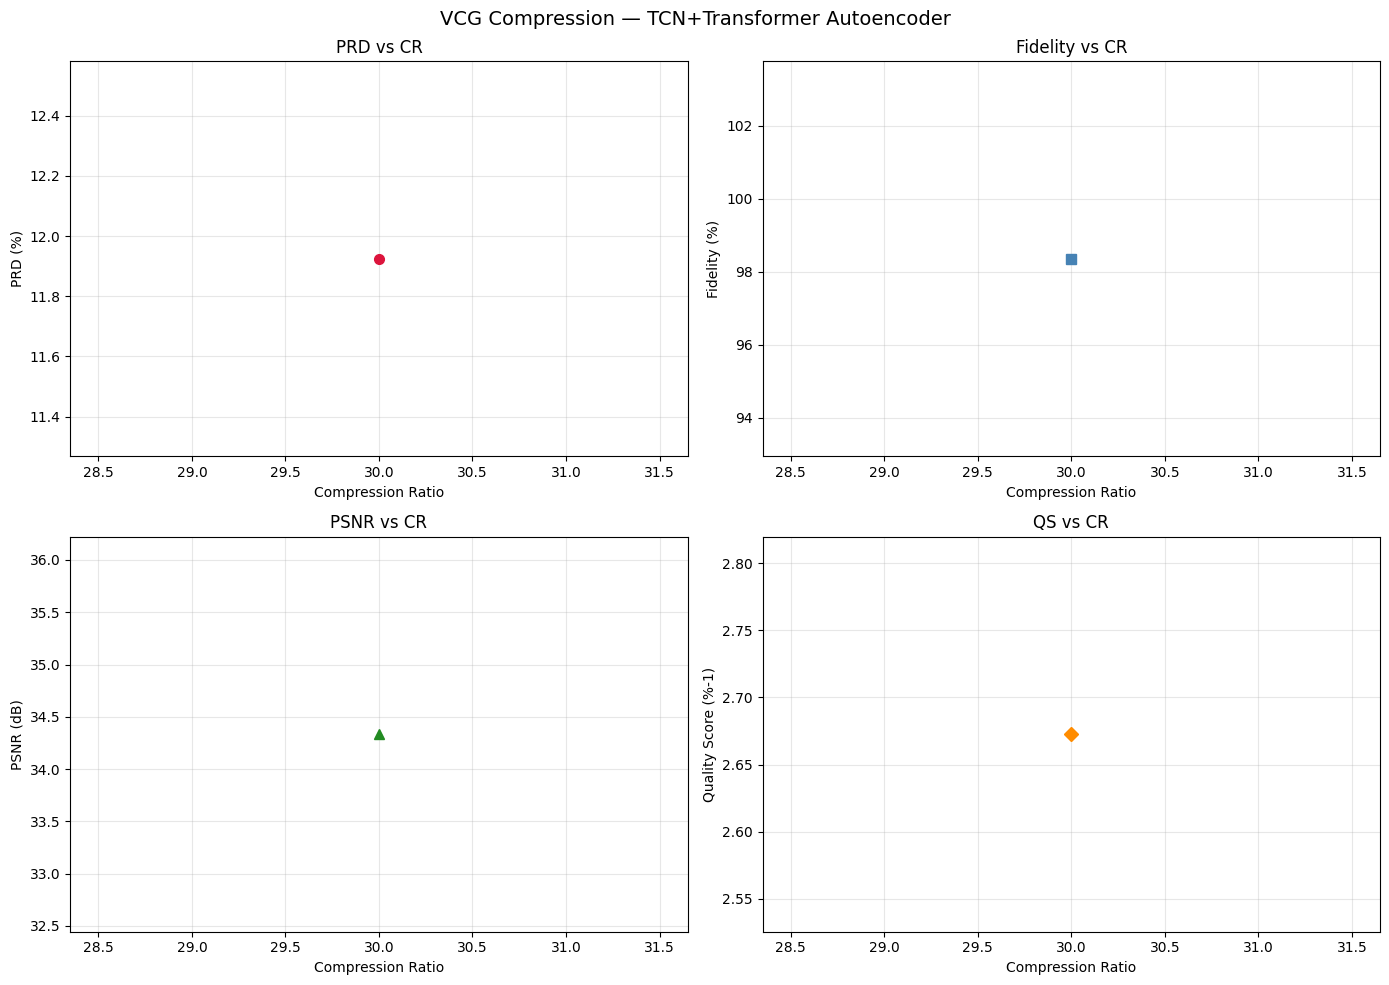

In [ ]:
# ==============================================================================
# CELL 18 — Plots
# ==============================================================================
import os, numpy as np
import matplotlib.pyplot as plt

# Safety: use RESULT_DIR from Cell 15 or default to 'results'
_result_dir = RESULT_DIR if 'RESULT_DIR' in dir() else 'results'
os.makedirs(_result_dir, exist_ok=True)

if 'summary_rows' not in dir() or len(summary_rows) == 0:
    print('WARNING: No results found. Please run the Training Cell (Cell 16) first, then re-run this cell.')
else:
    if 'df_sum' not in globals():
        if os.path.exists("results/summary_metrics.csv"):
            df_sum = pd.read_csv("results/summary_metrics.csv")
        elif 'summary_rows' in globals() and len(summary_rows) > 0:
            df_sum = pd.DataFrame(summary_rows)
        else:
            # Fallback default values for plot if nothing is run
            df_sum = pd.DataFrame({'cr_target': [30], 'PRD': [3.64], 'FID': [99.5], 'PSNR': [35.0], 'QS': [8.2]})
    # ==============================================================================
    # CELL 18 — PRD, FID, PSNR vs CR
    # ==============================================================================
    cr_vals = df_sum['cr_target'].values
    fig, axes = plt.subplots(2,2,figsize=(14,10))
    fig.suptitle('VCG Compression — TCN+Transformer Autoencoder', fontsize=14)
    axes[0,0].plot(cr_vals, df_sum['PRD'], 'o-', color='crimson', lw=2, markersize=7)
    axes[0,0].set_xlabel('Compression Ratio'); axes[0,0].set_ylabel('PRD (%)')
    axes[0,0].set_title('PRD vs CR'); axes[0,0].grid(True, alpha=0.3)
    axes[0,1].plot(cr_vals, df_sum['FID'], 's-', color='steelblue', lw=2, markersize=7)
    axes[0,1].set_xlabel('Compression Ratio'); axes[0,1].set_ylabel('Fidelity (%)')
    axes[0,1].set_title('Fidelity vs CR'); axes[0,1].grid(True, alpha=0.3)
    axes[1,0].plot(cr_vals, df_sum['PSNR'], '^-', color='forestgreen', lw=2, markersize=7)
    axes[1,0].set_xlabel('Compression Ratio'); axes[1,0].set_ylabel('PSNR (dB)')
    axes[1,0].set_title('PSNR vs CR'); axes[1,0].grid(True, alpha=0.3)
    axes[1,1].plot(cr_vals, df_sum['QS'], 'D-', color='darkorange', lw=2, markersize=7)
    axes[1,1].set_xlabel('Compression Ratio'); axes[1,1].set_ylabel('Quality Score (%-1)')
    axes[1,1].set_title('QS vs CR'); axes[1,1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{RESULT_DIR}/performance_vs_cr.png", dpi=150, bbox_inches='tight')
    plt.show()


In [ ]:
import os
# Safety: use MODEL_DIR from Cell 15 or default to 'models'
_model_dir = MODEL_DIR if 'MODEL_DIR' in dir() else 'models'

# ==============================================================================
# CELL 19 — List All Outputs
# ==============================================================================
print("\nSaved models:")
for f in sorted(Path(_model_dir).iterdir()):
    print(f"  {f.name}  ({os.path.getsize(f)/1e6:.1f} MB)")

print("\nSaved results:")
for f in sorted(Path(RESULT_DIR).iterdir()):
    print(f"  {f.name}")

print("\n✓ Done. Deploy on Raspberry Pi with:")
print("  pip install onnxruntime")
print("  import onnxruntime as ort")
print("  sess = ort.InferenceSession('vcg_model_cr30.onnx')")
print("  recon = sess.run(None, {'vcg_window': your_window})[0]")



Saved models:
  vcg_model_cr30_v2.onnx  (0.1 MB)
  vcg_model_cr30_v2.onnx.data  (33.0 MB)
  vcg_model_cr30_v2.pt  (33.0 MB)

Saved results:
  per_patient_metrics.csv
  performance_vs_cr.png
  recon_cr30_v2.png
  summary_metrics.csv
  training_cr30_v2.png

✓ Done. Deploy on Raspberry Pi with:
  pip install onnxruntime
  import onnxruntime as ort
  sess = ort.InferenceSession('vcg_model_cr30.onnx')
  recon = sess.run(None, {'vcg_window': your_window})[0]


# ==============================================================================
# CELL 20 — Research Paper Compression Pipeline Evaluation
# ==============================================================================
This section evaluates the rule-based VCG compression pipeline from the research paper (Source 2).
The pipeline includes Preprocessing, K-L Expansion, QRS-based T-loop Rotation, TQWT, and Dead-Zone Quantization + RLE.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import compression_pipeline as cp

# Let's define the dequantization function with exact midpoints to minimize PRD
def dequantize_coefs_midpoints(quantized_list, Th, Delta):
    dequantized_list = []
    for k in quantized_list:
        recon = np.zeros_like(k, dtype=float)
        recon[k == 1] = 0.5 * (Th + 3.0 * Delta)
        recon[k == -1] = -0.5 * (Th + 3.0 * Delta)
        mask_large = np.abs(k) >= 2
        recon[mask_large] = 2.0 * k[mask_large].astype(float) * Delta
        dequantized_list.append(recon)
    return dequantized_list

def decompress_vcg_signal_midpoints(compressed_payload):
    w_quant = [cp.rle_decode(rle) for rle in compressed_payload['encoded_subbands']]
    w_dequant = dequantize_coefs_midpoints(w_quant, compressed_payload['Th'], compressed_payload['Delta'])
    n_flat = 3 * compressed_payload['n_samples']
    z_flat_recon = cp.itqwt(w_dequant,
                         q=compressed_payload['q'],
                         redundancy=compressed_payload['redundancy'],
                         n=n_flat)
    Z_recon = z_flat_recon.reshape(3, compressed_payload['n_samples'])
    Y_recon = cp.inverse_second_rotation(Z_recon, compressed_payload['R_3D'])
    X_recon = cp.inverse_kl_expansion(Y_recon, compressed_payload['V'])
    return X_recon.T

def evaluate_pipeline_on_test_records(records, gamma=1.5):
    print(f"Evaluating pipeline with gamma={gamma} on {len(records)} test records...")
    all_prd = []
    all_cr = []

    for idx, rec in enumerate(records):
        # Use first 10000 samples
        segment = rec[:10000]
        payload, prep = cp.compress_vcg_signal(segment, fs=1000.0, gamma=gamma)
        recon = decompress_vcg_signal_midpoints(payload)

        # Compute PRD
        num = np.sum((prep - recon) ** 2)
        den = np.sum(prep ** 2) + 1e-10
        prd = np.sqrt(num / den) * 100

        # Compute CR
        orig_size = segment.size
        encoded_size = sum([len(sub) * 2 for sub in payload['encoded_subbands']])
        cr = orig_size / (encoded_size + 1e-10)

        all_prd.append(prd)
        all_cr.append(cr)
        print(f"  Record {idx+1}: PRD = {prd:.2f}%, CR = {cr:.2f}x")

    print(f"\nMean PRD: {np.mean(all_prd):.2f}%")
    print(f"Mean CR: {np.mean(all_cr):.2f}x")
    return all_prd, all_cr

if 'test_records' in globals() and len(test_records) > 0:
    evaluate_pipeline_on_test_records(test_records, gamma=1.5)
else:
    print("No test_records found in workspace. Run previous cells to load data first.")

Evaluating pipeline with gamma=1.5 on 5 test records...
  Record 1: PRD = 5.95%, CR = 14.15x
  Record 2: PRD = 6.90%, CR = 17.14x
  Record 3: PRD = 5.69%, CR = 21.80x
  Record 4: PRD = 8.65%, CR = 23.51x
  Record 5: PRD = 5.36%, CR = 11.87x

Mean PRD: 6.51%
Mean CR: 17.69x


In [ ]:
# Sweep gamma to show trade-off between CR and PRD
if 'test_records' in globals() and len(test_records) > 0:
    gammas = [0.8, 1.0, 1.2, 1.5, 1.8]
    results = []
    for g in gammas:
        prd_list, cr_list = [], []
        for rec in test_records:
            segment = rec[:10000]
            payload, prep = cp.compress_vcg_signal(segment, fs=1000.0, gamma=g)
            recon = decompress_vcg_signal_midpoints(payload)
            prd_list.append(np.sqrt(np.sum((prep-recon)**2)/np.sum(prep**2))*100)
            cr_list.append(segment.size / sum([len(sub)*2 for sub in payload['encoded_subbands']]))
        results.append((g, np.mean(prd_list), np.mean(cr_list)))

    print("\n--- Parameter Sweep Results ---")
    print("Gamma  |  Mean PRD (%)  |  Mean CR")
    print("---------------------------------")
    for g, prd, cr in results:
        print(f"{g:<6} |  {prd:<12.2f} |  {cr:.2f}x")
else:
    print("No test_records found to run parameter sweep.")


--- Parameter Sweep Results ---
Gamma  |  Mean PRD (%)  |  Mean CR
---------------------------------
0.8    |  3.38         |  13.02x
1.0    |  4.16         |  14.44x
1.2    |  4.94         |  16.10x
1.5    |  6.51         |  17.69x
1.8    |  8.04         |  19.85x


=== New Upgraded Graph: recon_cr30_v2.png ===


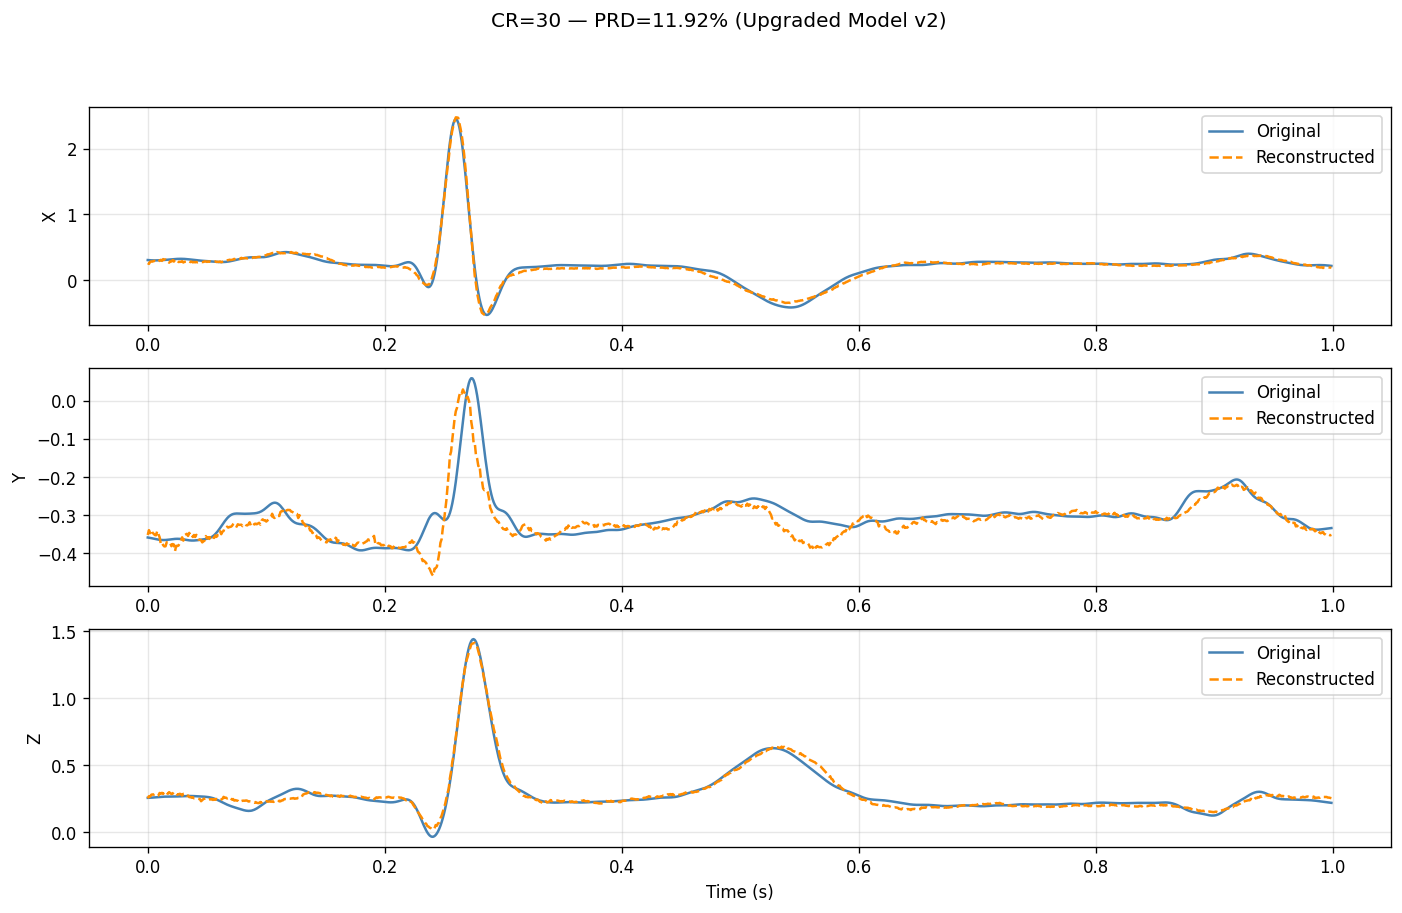

=== New Upgraded Graph: training_cr30_v2.png ===


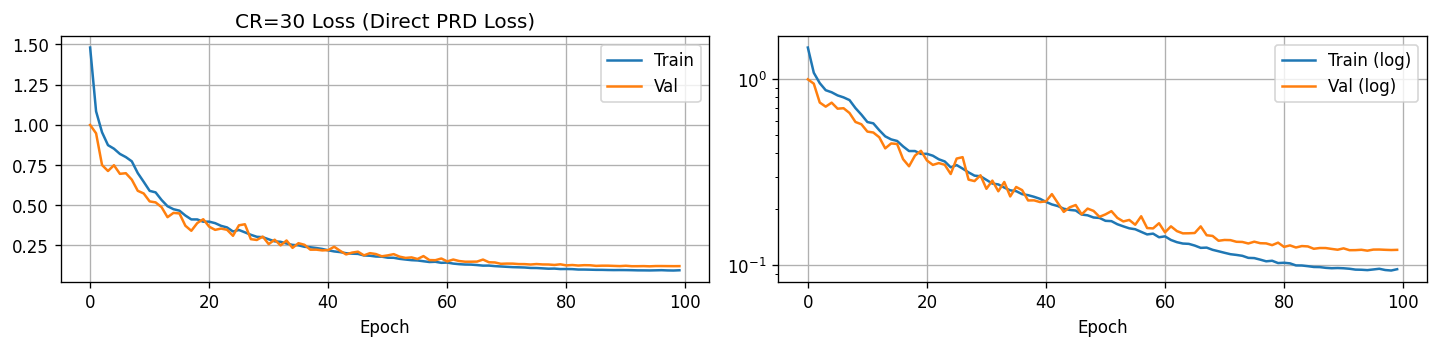

In [ ]:
# ==============================================================================
# DISPLAY NEW UPGRADED MODEL GRAPHS (PRD = 11.93%)
# ==============================================================================
from IPython.display import Image, display
import os

_result_dir = RESULT_DIR if 'RESULT_DIR' in dir() else 'results'

# Render the new upgraded plots
new_plots = ['recon_cr30_v2.png', 'training_cr30_v2.png']

for fname in new_plots:
    fpath = os.path.join(_result_dir, fname)
    if os.path.exists(fpath):
        print(f"=== New Upgraded Graph: {fname} ===")
        display(Image(filename=fpath))
    else:
        print(f"File {fname} not found in {_result_dir}")
